# 08 N材/L材混合比率推定の可能性評価

06/07の分類可能性評価とは切り分けて、ここでは **N材/L材が混ざったパルプシートの平均的な混合比率を、スペクトルから回帰で推定できるか** を確認します。

現時点では既知配合比の実混合パルプシートが無いため、まずは含水率が近いN材・L材の単独スペクトルを組み合わせ、rawスペクトルを線形混合した疑似混合データで予備評価します。これは実パルプシートの散乱、繊維長、密度、叩解、配向、非線形混合を完全に再現するものではなく、あくまでモデル上の比率推定可能性を見るための検証です。


## 方法論の整理

- 分類モデルの確率は、物理的なN材/L材比率そのものではないため、最終目的は **N材比率またはL材比率を目的変数にした回帰モデル** として扱います。
- パルプシート状態で既に混ざっている前提では、カメラによる空間分布推定ではなく、測定スペクトルから **バルク平均の混合比率** を推定するモデル設計を優先します。
- 実運用に向けては、N/L = 0/100, 10/90, ..., 100/0 などの既知配合比シートを複数ロット・含水率・坪量・叩解条件で作成し、外部検証でRMSE/MAE/bias/許容誤差内率を確認する必要があります。
- 本ノートでは、含水率差が小さいN/Lペアを作り、0, 10, ..., 100%の疑似混合スペクトルを生成して、PLS回帰/Ridgeを中心に予備評価します。


In [1]:
# 08用の解析を実行します。
# 出力先: outputs/reports/08_nl_mixture_ratio_estimation/<run_id>/
%run build_08_nl_mixture_ratio_assets.py


/Users/ogawatomohiro/myproject/my-notebooks/build_08_nl_mixture_ratio_assets.py:331: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["wood_type"] = df[SPECIES_NUMBER_COL].astype(int).map(WOOD_TYPE_MAPPING)
/Users/ogawatomohiro/myproject/my-notebooks/build_08_nl_mixture_ratio_assets.py:332: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["nl_label"] = df["wood_type"].map(NL_LABEL_MAPPING)


outputs/reports/08_nl_mixture_ratio_estimation/20260518_075839
{
  "range": "full",
  "preprocess": "snv",
  "model": "ridge",
  "rmse_percent_point": 5.963976344541886,
  "mae_percent_point": 3.9559071855986403,
  "r2": 0.9644309861617448,
  "bias_percent_point": -0.309303043648963,
  "within_5pt_rate": 0.7254545454545455,
  "within_10pt_rate": 0.926060606060606
}


In [2]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown

base = Path('outputs/reports/08_nl_mixture_ratio_estimation')
latest = sorted([p for p in base.iterdir() if p.is_dir()])[-1]
summary = json.loads((latest / 'summary.json').read_text(encoding='utf-8'))
latest, summary['best_model']


(PosixPath('outputs/reports/08_nl_mixture_ratio_estimation/20260518_075839'),
 {'range': 'full',
  'preprocess': 'snv',
  'model': 'ridge',
  'rmse_percent_point': 5.963976344541886,
  'mae_percent_point': 3.9559071855986403,
  'r2': 0.9644309861617448,
  'bias_percent_point': -0.309303043648963,
  'within_5pt_rate': 0.7254545454545455,
  'within_10pt_rate': 0.926060606060606})

In [3]:
display(Markdown((latest / 'methodology.md').read_text(encoding='utf-8')))


# 08 N材/L材混合比率推定 方法論メモ

目的は、N材/L材が混ざって作られたパルプシートについて、スペクトルからN材比率またはL材比率を推定できるかを評価することである。

## 基本方針

- 分類モデルの確率は、物理的な混合比率そのものではないため、最終的には既知配合比の校正試料を作り、比率を目的変数とした回帰モデルとして構築する。
- パルプシート状態で既に混ざっている前提では、カメラによる空間分布推定ではなく、測定スペクトルから平均的な混合比率を推定するモデル設計を優先する。
- 本08では、現時点のN材/L材単独スペクトルから含水率が近いペアを作り、rawスペクトルを線形混合した疑似混合スペクトルで予備的な可能性評価を行う。
- 疑似混合は実混合パルプの散乱、繊維長、密度、叩解、配向、非線形性を完全には再現しない。したがって、ここでの結果は「モデル上、N/L差が比率情報として使えそうか」の予備評価である。

## 実試料で次に必要なこと

- N/L = 0/100, 10/90, ..., 100/0 など既知配合比のパルプシートを作る。
- ロット、含水率、シート密度、坪量、叩解条件などを変え、比率以外の変動をモデルに学習させる。
- PLS回帰を基準モデルにし、Ridge、SVR、GPR、RandomForest回帰などと比較する。
- 評価はRMSE、MAE、bias、R²、±5%以内/±10%以内の割合で行い、ロットや作製日をまたぐ外部検証を重視する。


In [4]:
scores = pd.read_csv(latest / 'mixture_ratio_cv_scores.csv')
display(scores.head(12))


,range,preprocess,model,rmse_percent_point,mae_percent_point,r2,bias_percent_point,within_5pt_rate,within_10pt_rate
0,full,snv,ridge,5.963976,3.955907,0.964431,-0.309303,0.725455,0.926061
1,full,snv_deriv1,ridge,6.065309,4.202590,0.963212,-0.213058,0.692121,0.917576
2,full,snv_deriv1,pls_10,6.309889,4.321884,0.960185,-0.191468,0.691818,0.903939
3,full,snv_deriv2,pls_10,6.942632,4.929098,0.951800,-0.214038,0.613636,0.883636
4,full,snv_deriv2,pls_5,8.037961,5.724041,0.935391,-0.215905,0.554848,0.830909
5,900-1700nm,snv_deriv1,ridge,8.579202,6.092438,0.926397,-0.241717,0.527879,0.815152
6,900-1700nm,snv,ridge,8.621606,6.222250,0.925668,-0.160906,0.509394,0.808182
7,900-1700nm,snv_deriv1,pls_10,8.756957,6.258773,0.923316,-0.186714,0.524242,0.799697
8,900-1700nm,raw_scaled,pls_10,8.862825,6.382250,0.921450,0.205546,0.484545,0.822424
9,full,raw_scaled,ridge,9.251610,6.509873,0.914408,0.127480,0.513636,0.817576


In [5]:
error_by_ratio = pd.read_csv(latest / 'mixture_ratio_error_by_ratio.csv')
display(error_by_ratio)


,n_ratio_percent,n,mean_pred,mae,bias,p95_abs_error
0,0.0,300,4.949017,4.949017,4.949017,17.787611
1,10.0,300,12.442265,4.379472,2.442265,14.053809
2,20.0,300,21.122607,3.808868,1.122607,10.836125
3,30.0,300,30.029171,3.737472,0.029171,8.600522
4,40.0,300,39.172220,3.821670,-0.827780,9.174976
5,50.0,300,48.559005,4.023794,-1.440995,9.491501
6,60.0,300,58.194588,4.076423,-1.805412,11.640238
7,70.0,300,68.086525,4.005748,-1.913475,11.959006
8,80.0,300,78.252473,3.814501,-1.747527,11.977673
9,90.0,300,88.715690,3.972116,-1.284310,11.866951


mixture_design outputs/reports/08_nl_mixture_ratio_estimation/20260518_075839/figures/mixture_design.png


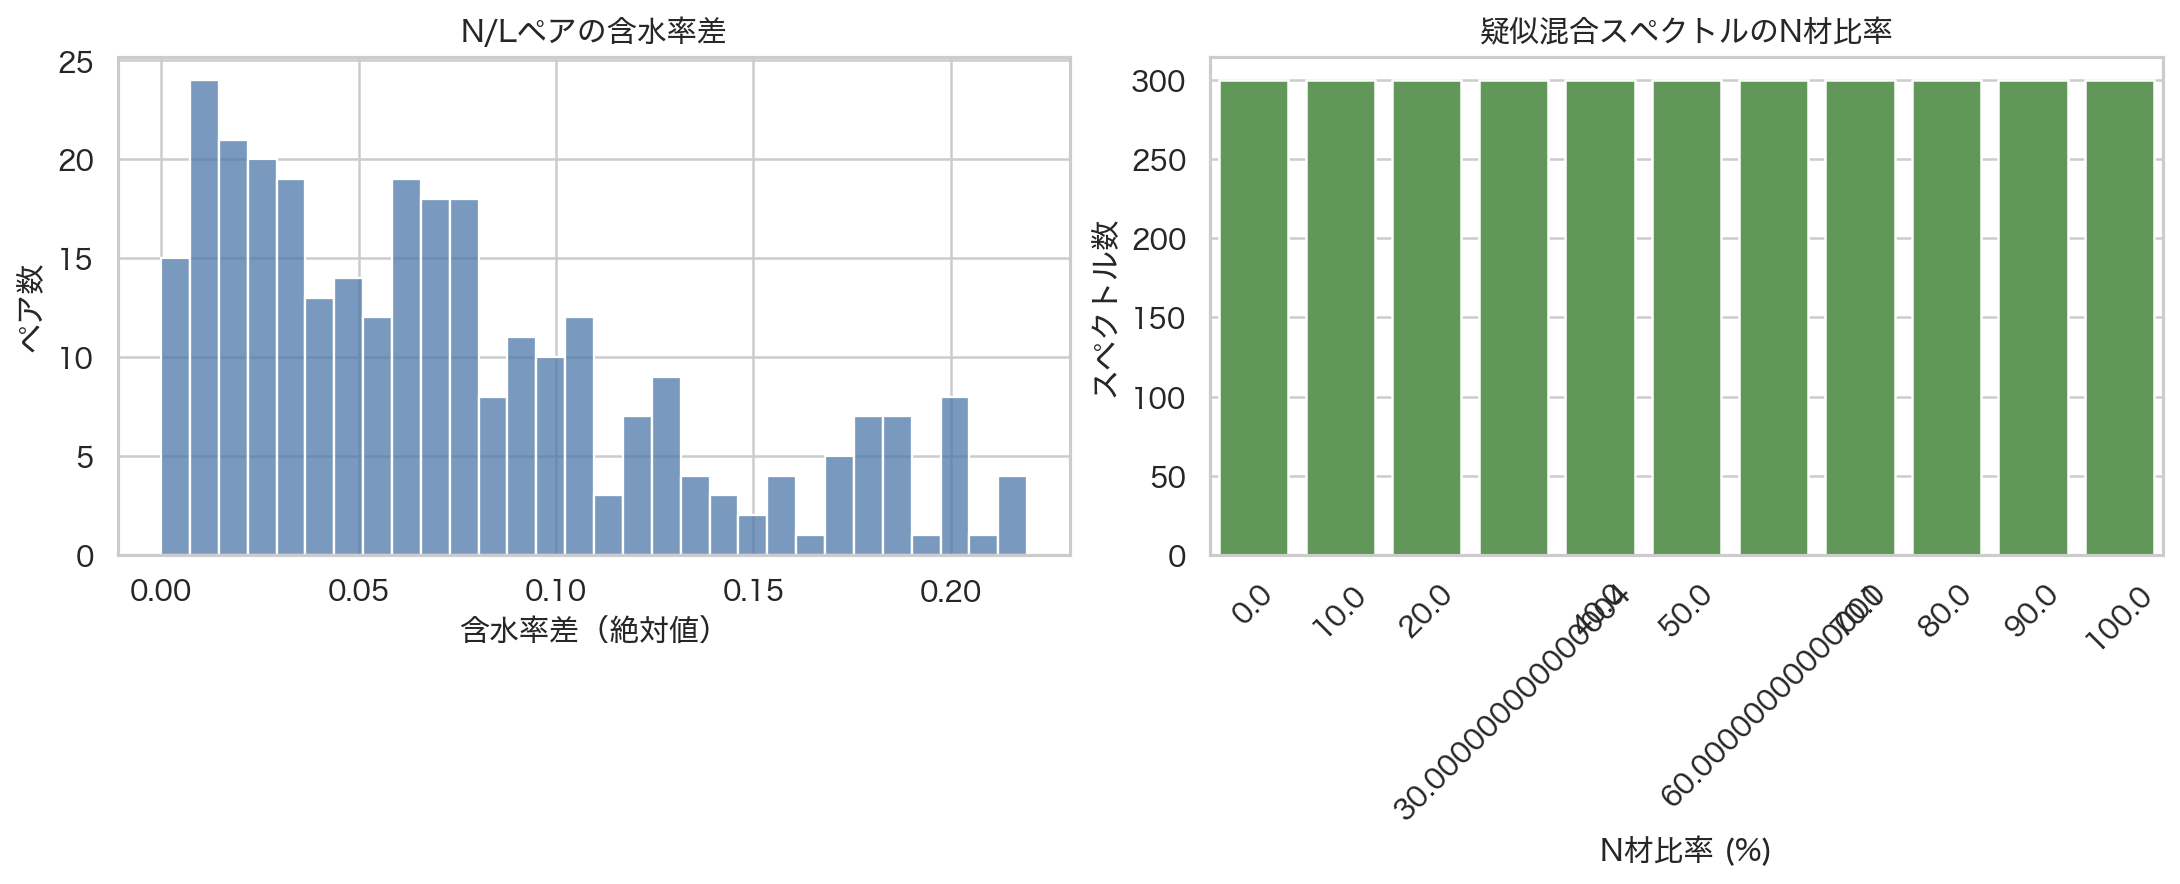

example_mixed_spectra outputs/reports/08_nl_mixture_ratio_estimation/20260518_075839/figures/example_mixed_spectra.png


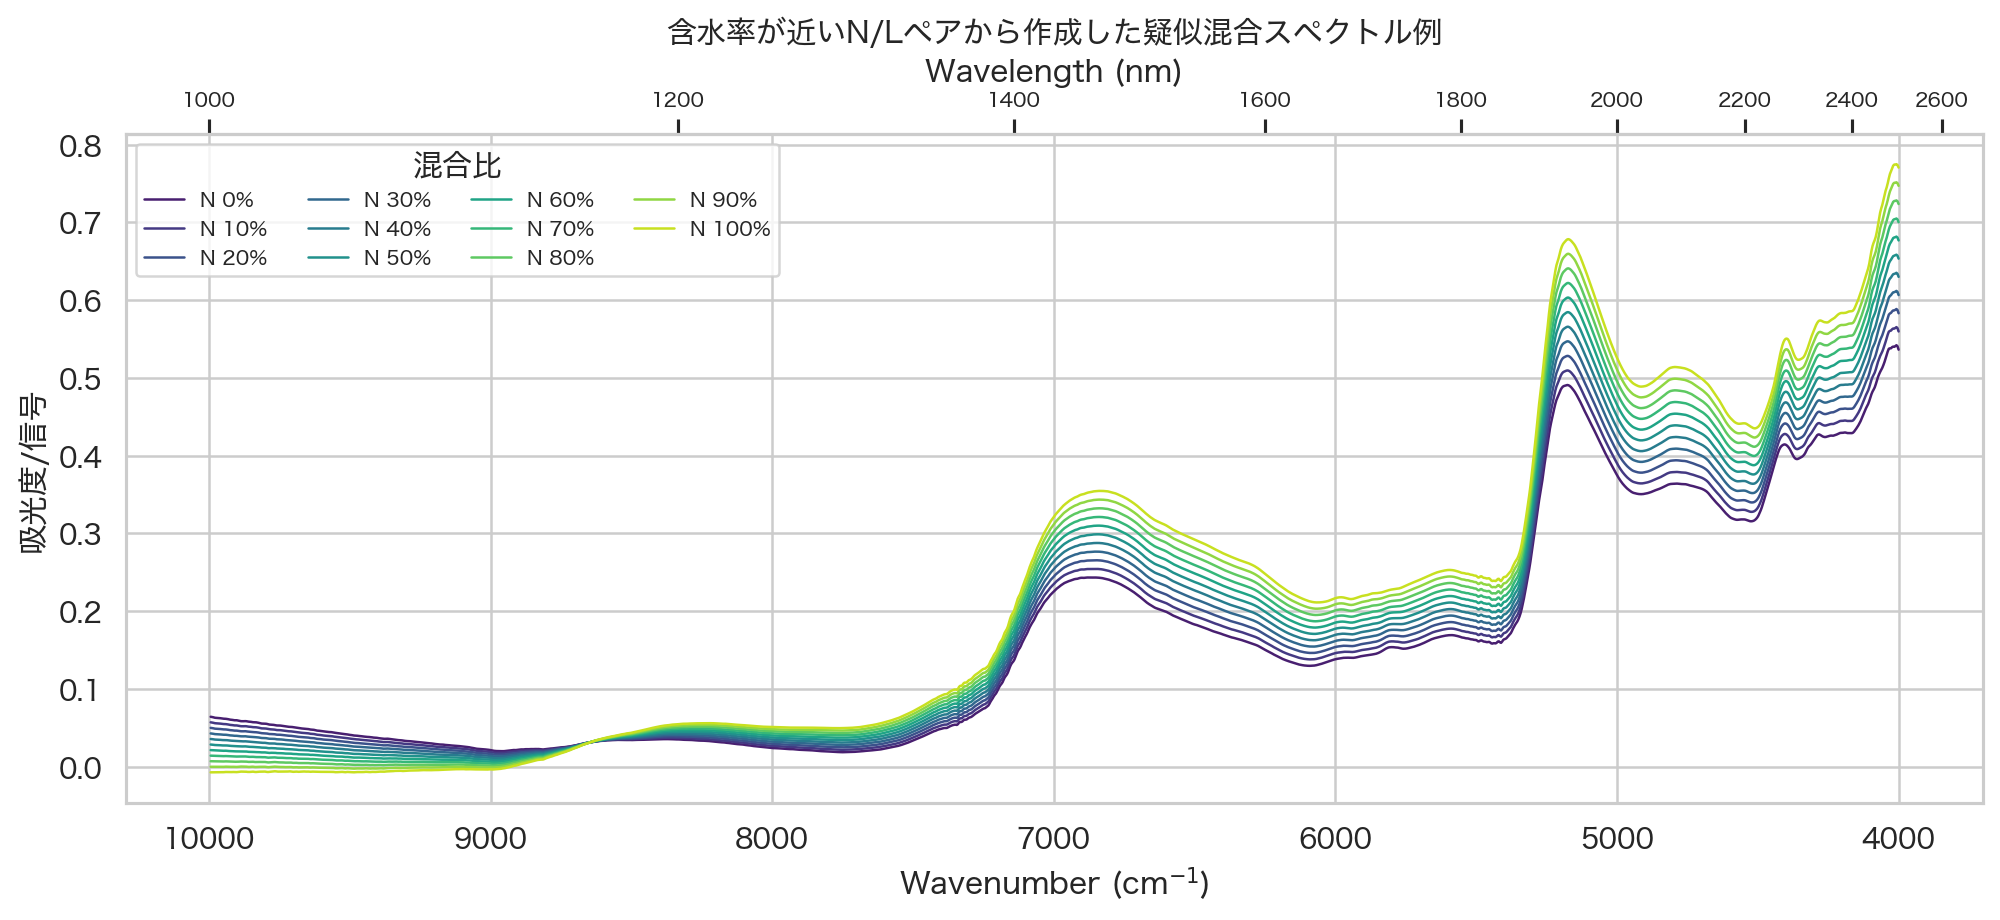

model_comparison outputs/reports/08_nl_mixture_ratio_estimation/20260518_075839/figures/model_comparison_rmse.png


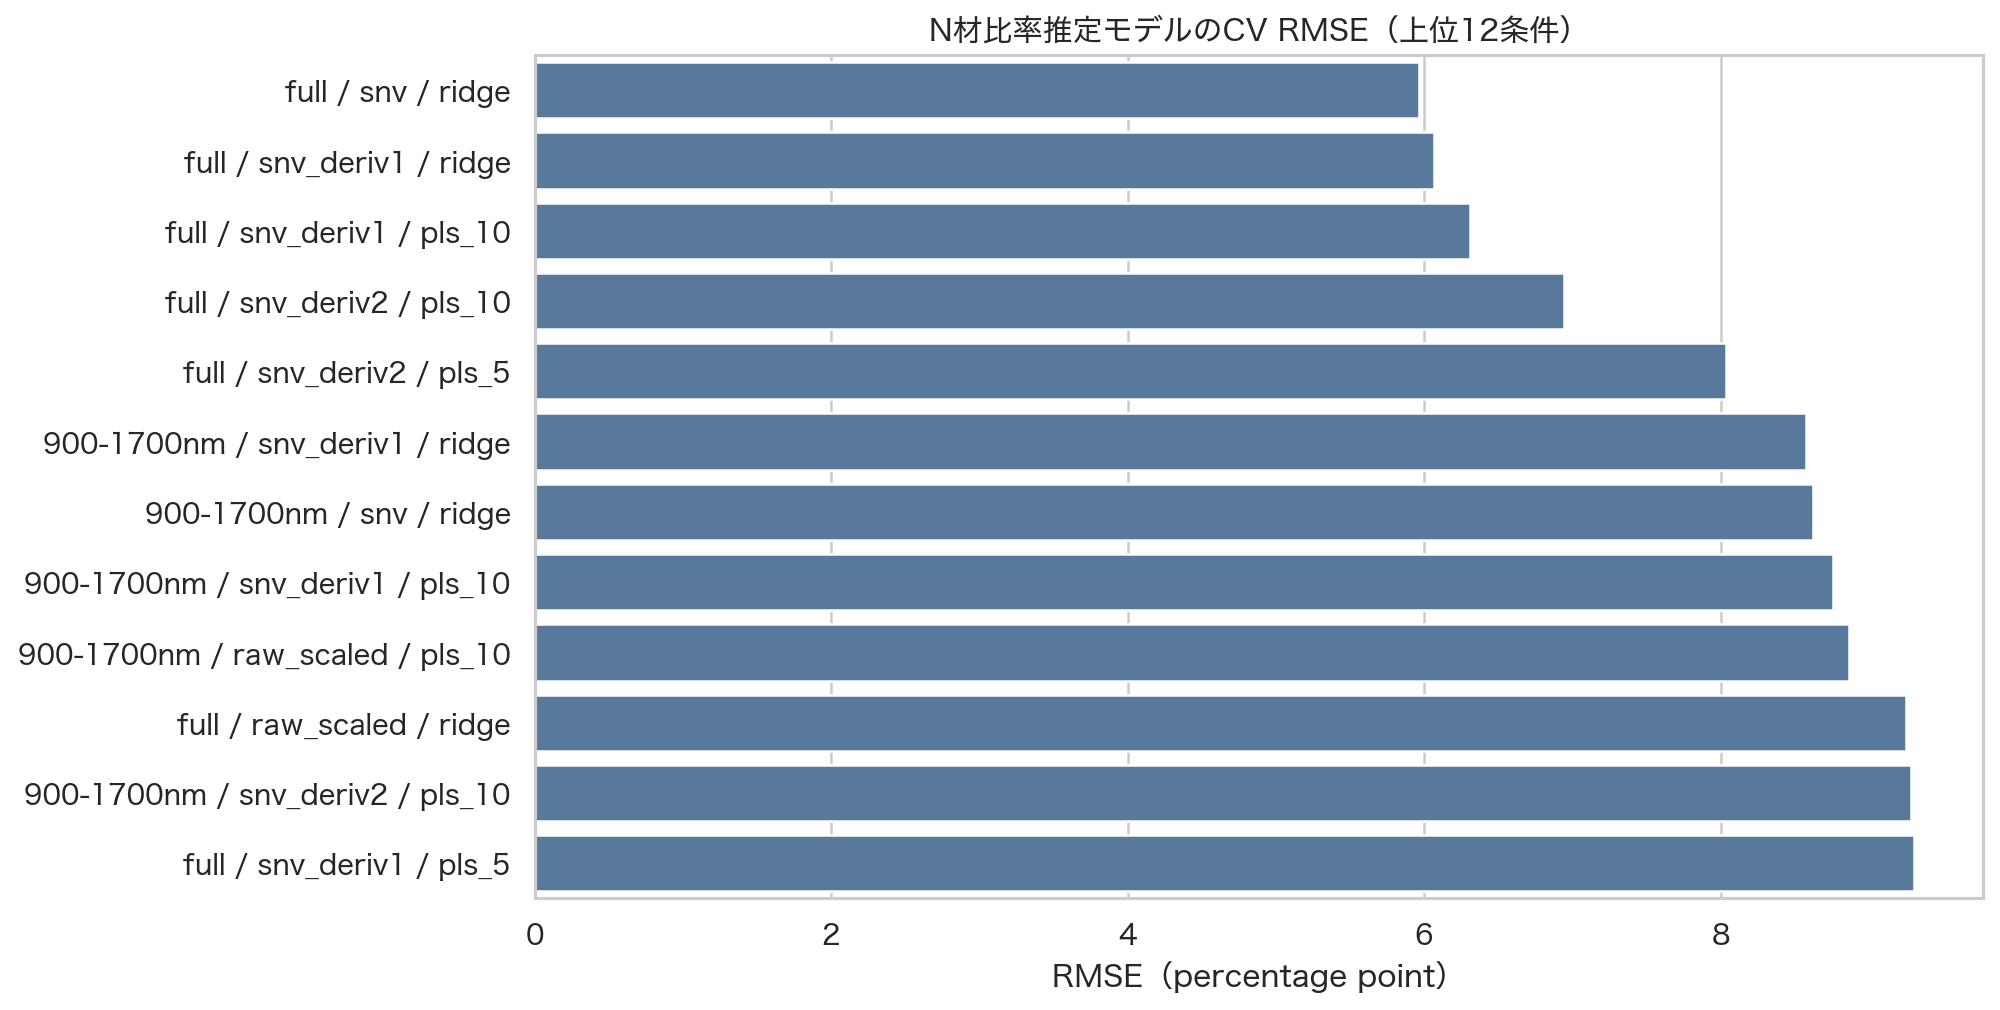

actual_vs_predicted outputs/reports/08_nl_mixture_ratio_estimation/20260518_075839/figures/actual_vs_predicted_best.png


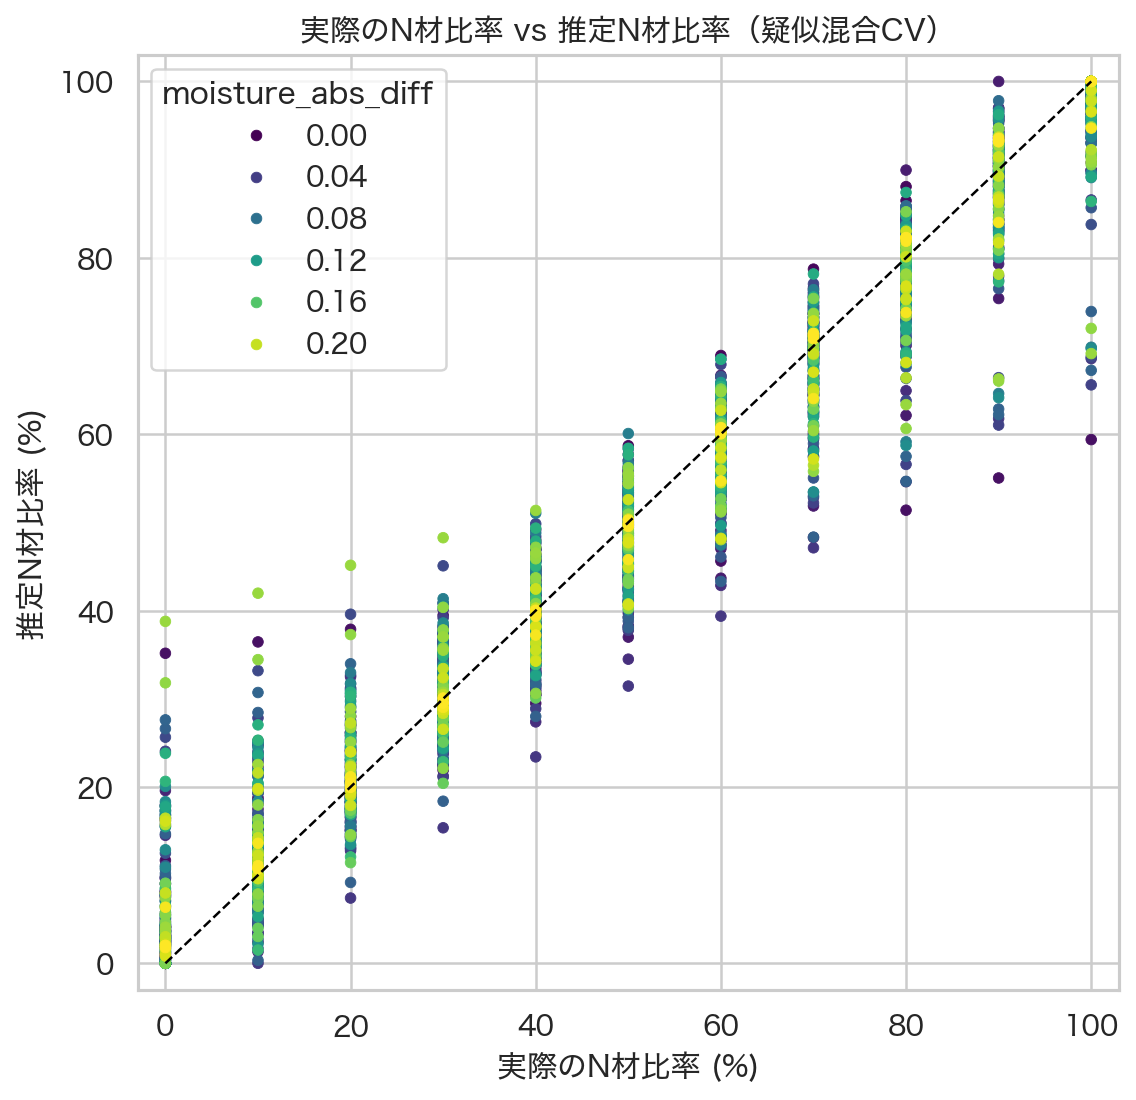

error_by_ratio outputs/reports/08_nl_mixture_ratio_estimation/20260518_075839/figures/error_by_ratio.png


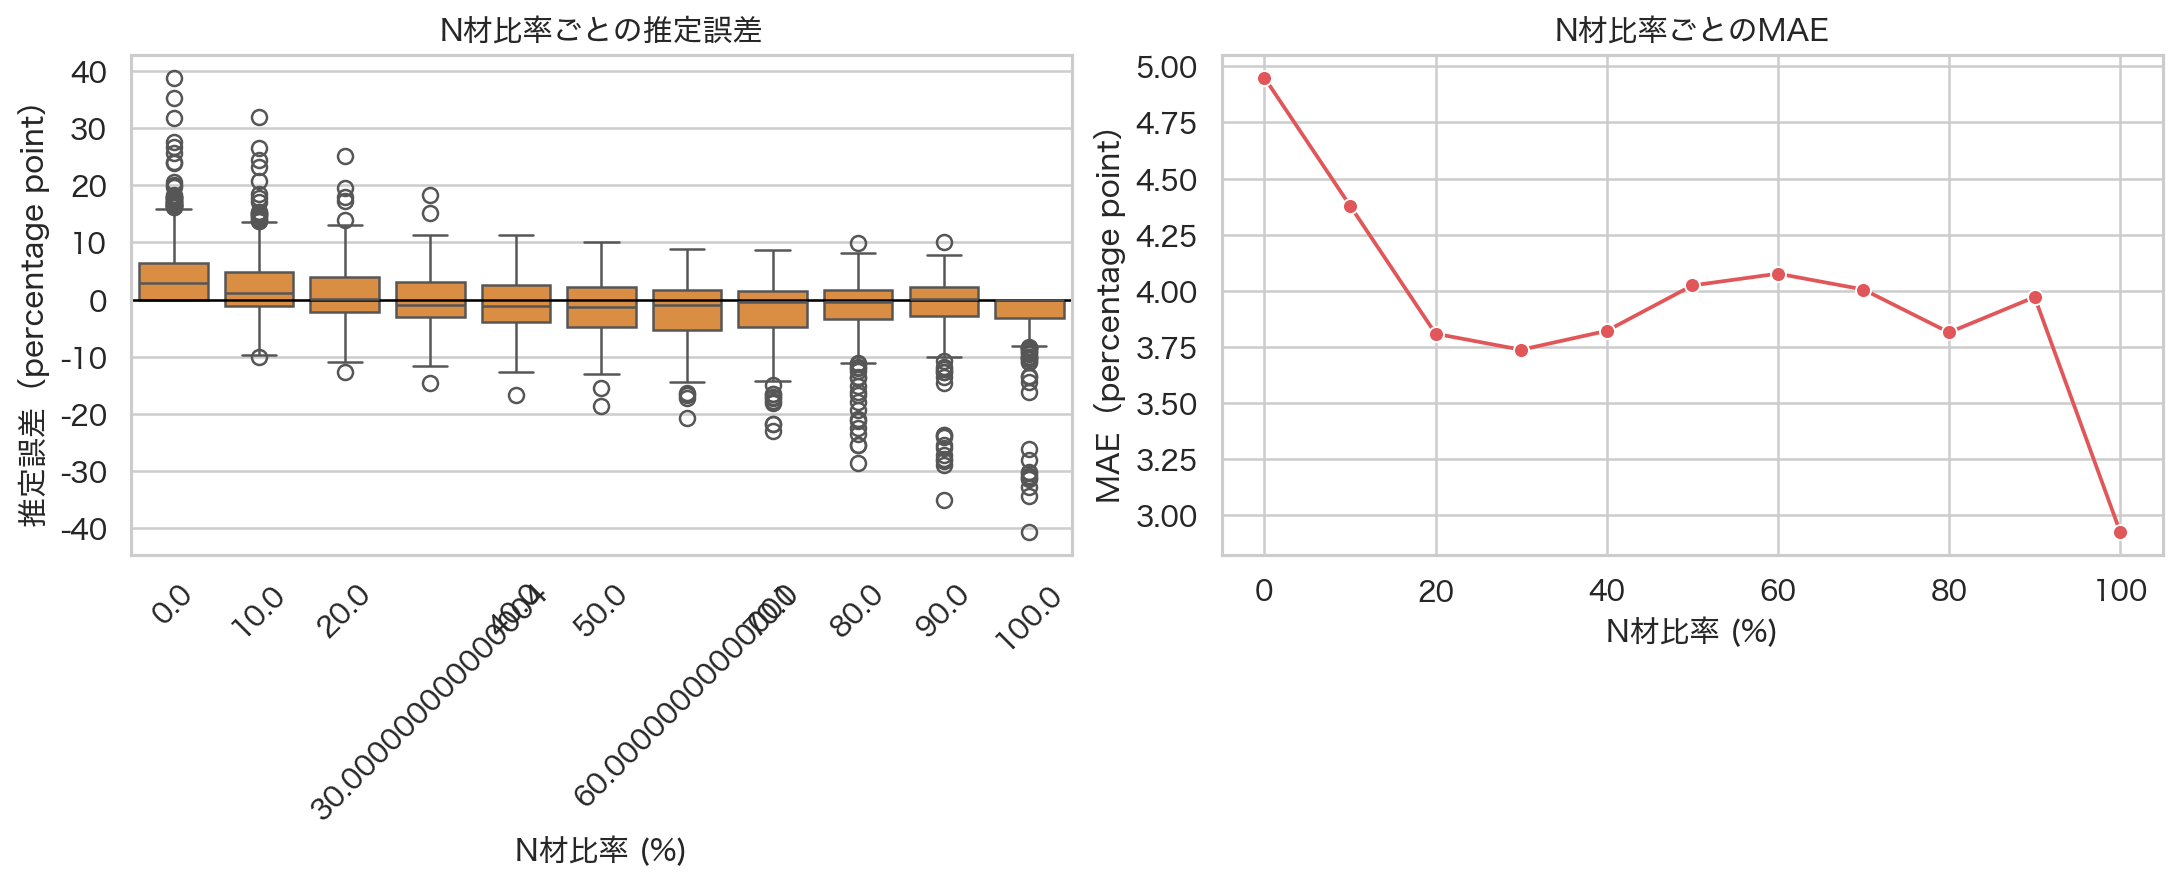

In [6]:
for name, fig_path in summary['figures'].items():
    print(name, fig_path)
    display(Image(filename=fig_path))


## 現時点の読み方

疑似混合スペクトルで良好な結果が出る場合、N材/L材のスペクトル差が比率情報としてモデルに使える可能性があります。ただし、この評価は単独材スペクトルの線形混合に基づくため、実際の混合パルプシートにそのまま適用できる保証ではありません。

次に必要なのは、既知比率で作成した実混合パルプシートを使い、同じ評価軸で外部検証することです。特に含水率、シート密度、坪量、叩解条件、測定位置のばらつきが比率推定より強く効かないかを確認します。
